# MAIT 1h 降水自适应集成 — 原理、参数与应用

本文档说明仓库 **MAIT 1h** 的**业务场景**、**主流程**与**调用方式**，与 **`docs/MAIT_1H_程序说明.md`** §1–§7 保持一致。  
**§8 起为 notebook 独有**：改造前后对比与结果检验。

**核心源码**：

| 模块 | 文件 |
|------|------|
| 主入口 / 命令行 | `src/mait_1h_cli.py` — `process()` / `RunProcess` / Clize CLI |
| 权重与插值 | `src/mait_1_plugin.py` |
| 读数与时间 | `src/mait_1_plugin_util.py` |
| 运行上下文 | `utils/mai_1_plugin_context.py` — `RunContext` |
| 配置与 I/O | `utils/util_env.py`、`utils/util_new.py` |
| 运行默认项 | `resource/mait_1.ini` |

---


## 1. 适用场景

| 场景 | 说明 |
|------|------|
| **1h 多模式集成** | 读取多套模式的 **Micaps3 站点** 1h 降水，按子区 TS 动态加权，经频率匹配订正后写出站点产品，再插值到格点。 |
| **逐起报、逐时效批处理** | 支持多个 `time_input`；每个起报对 `predict_valid_list`（默认 **1–48 h**）逐小时循环。 |
| **分区权重** | `split_lat × split_lon` 划分子区；`area_scale=0.5` 扩展训练邻域后分别算 TS 与权重。 |
| **双路 TS** | **近 10 日**同时效样本 → `score_before`；**当前时效前 1 h** 样本 → `score_now`；`score_last = 0.5×score_before + 0.5×score_now`。 |
| **Micaps 产品** | 站点 **Micaps3**（`staoutputPath`）；格点 **Micaps4 + NC**（`write_grid_to_micaps4`）。 |
| **服务区约束** | 插值掩膜 `mask010.dat`；写出前按 `clip_coords` 裁剪格点。 |

---


## 2. 主流程（`RunProcess._process_single`）

### 2.1 初始化（`_setup_context`）

1. `os.chdir` → **`src/`**  
2. `get_resolved_paths()` → **`mait_1.ini`**  
3. `_prepare`：12 位 `%Y%m%d%H%M` → `dt_now`，读 `sta.info`  
4. `_analysis_para_ini`：读 **`para.ini`**（或 `para_1.ini`，由 `para_ini` 指定）  
5. `_analysis_background_ini` → **`para_1_background.ini`**  
6. `build_run_context`；background 缺键 → `ctx=None` 退出  

### 2.2 按时效循环

| 步骤 | 函数 | 要点 |
|------|------|------|
| 历史样本 | `_read_history_source_micaps3` | 昨日 fact + 模式 M3；**实况缺失则中断** |
| 评分样本 | `_read_mait_st_like_score_samples` | 10 日 + front 1h |
| 当前读数 | `_read_now_source_micaps3_nc` | M3 + 背景 M4；`dt_search_base` |
| 质检 | `DataFlgProcess` | 当前全缺 → `continue` 跳过 |
| TS 融合 | `AnalysisTsWeightProcess` | TS 0.1/1/5/10；beta 链关闭 |
| 站点 | `mait_1h_cli` | `id` 去重；**`data0×1.2`** |
| 格点 | `StationDataInterp2GridDataProcess` | Cressman + 掩膜 + FM |
| 写出 | `write_grid_to_micaps4` | `.m4` + `.nc` |

**不足 48 时效**：配置为 1–48，但模式全缺会跳过；历史 fact 缺失会中断。

### 2.3 读数分工

| 数据 | 配置 | 说明 |
|------|------|------|
| 模式 M3 | para | VVV→TTT；36h 回溯 |
| 背景 M4/NC | `para_1_background.ini` | 仅 TTT；无文件 → 全 0 格点 |
| 实况 | para 的 `fact` | `is_obs_bjt` 对齐 |

### 2.4 `dt_search_base`

`is_obs_bjt=True` 时 **`dt_now−8h`** → 用于检索与 **`grid_base.gtime`**（输出文件名 UTC 时刻）。  
例：北京 `202507020000` → 输出 `2025070116.VVV.*`。


### 2.5 ### 2.5 数据流示意

```mermaid
flowchart TD
    A[_setup_context: mait_1.ini + para + background ini] --> B[按 predict_valid 循环]
    B --> C[历史 + 10日/front 样本]
    C --> D[当前 M3 + 背景 M4]
    D --> E[DataFlgProcess]
    E --> F[AnalysisTsWeightProcess]
    F --> G[Micaps3 站点 data0×1.2]
    G --> H[Cressman 插值 + 掩膜]
    H --> I[Micaps4/NC + clip_coords]
```

---


## 3. 目录与核心文件

| 路径 | 作用 |
|------|------|
| `src/mait_1h_cli.py` | 主入口 |
| `src/mait_1_plugin.py` | TS、Cressman、DataFlg |
| `src/mait_1_plugin_util.py` | 读数、background、回溯 |
| `utils/mai_1_plugin_context.py` | `RunContext`、`dt_search_base` |
| `utils/base_plugin.py` | `PostProcessingPlugin` 基类 |
| `utils/multipro_plugin.py` | `SimpleParallelTool` 多进程 |
| `utils/util_env.py` | `mait_1.ini` 配置解析 |
| `utils/util_new.py` | 掩码、Micaps、FM、全 0 背景 |
| `utils/data_prepare_plugin.py` | meteva 数据集准备（辅） |
| `utils/data_distribute_pulgin.py` | 数据文件分发（辅） |
| `src/mait_1_verify.py` | 检验脚本 |
| `test/mait_1_nimm_test.py` | 批量起报测试 |
| `cli/__main__.py` | `python -m cli` 转发至 `src/mait_1h_cli.py` |

## 4. 算法要点

- **TS**：阈值 0.1/1/5/10 mm，权重 0.3/0.2/0.25/0.25；`score_last = 0.5×before + 0.5×now`  
- **融合**：线性加权 + `MetevaFrequencyMatch`  
- **格点**：Cressman 0.6/0.4/0.2/0.1 → 平滑 10 次 → 格点 FM → 极值处理  

---


## 4. 算法要点

- **TS**：阈值 0.1/1/5/10 mm，权重 0.3/0.2/0.25/0.25；`score_last = 0.5×before + 0.5×now`  
- **融合**：线性加权 + `MetevaFrequencyMatch`  
- **格点**：Cressman 0.6/0.4/0.2/0.1 → 平滑 10 次 → 格点 FM → 极值处理  

---


## 5. 配置文件说明

| 文件 | 内容 |
|------|------|
| `resource/mait_1.ini` | 日志、**`para_ini`**、background、mask、clip、时效、多进程 |
| `resource/para.ini` / `para_1.ini` | 模式 M3、`fact`、`staoutputPath`（GBK） |
| `resource/para_1_background.ini` | 背景 M4/NC，键名与 para 一致 |
| `resource/sta.info` | 站点表 |
| `resource/mask010.dat` | 插值掩膜 |

**重要**：程序只读 `mait_1.ini` 里 **`para_ini=`** 指定的文件；生产环境请设 `para_ini=resource/para_1.ini` 或 `--para-path`。

---


## 6. `process()` 参数

**调用链**：`python -m cli` / `python src/mait_1h_cli.py` → `process()` → `RunProcess._process_single()`。

| 参数 | 作用 | `None` 时 |
|------|------|----------|
| `time_inputs` | 起报列表（12 位） | CLI 必填 |
| `predict_valid_list` | 时效循环 | ini：1…48 |
| `para_path` | para 文件 | ini：`para_ini` |
| `beta_path` | beta 模板（主循环未用 npy 链） | ini |
| `is_obs_bjt` | 是否减 8h | ini：`is_obs_bj` |
| `is_multi` / `pro_count` | 多进程 | ini |
| `clip_coords` / `split_lat` / `split_lon` | 裁剪与分区 | ini |

---


## 7. CLI 示例

```text
python -m cli --time-inputs=202605260800
python src/mait_1h_cli.py --time-inputs=202507020000 --para-path=resource/para_1.ini
python -m cli --help
```

| CLI 选项 | `process` 参数 |
|----------|----------------|
| `--time-inputs` | `time_inputs` |
| `--predict-valid-list` | `predict_valid_list` |
| `--para-path` | `para_path` |
| `--beta-path` | `beta_path` |
| `--is-obs-bjt` | `is_obs_bjt` |
| `--is-multi` | `is_multi` |
| `--clip-coords` | `clip_coords` |
| `--pro-count` | `pro_count` |
| `--split-lat` / `--split-lon` | `split_lat` / `split_lon` |

依赖：`pip install -r requirements-cli.txt`；失败时查 `log/YYYYMMDD.txt`。


## 8. 当前NIMM标准化格式改造版本与原程序版本结果对比
两个版本以一致的输入数据进行融合，对融合预报结果数值进行对比


m4 文件时间格式错误，因此数据时间被强制设置为2099年1月1日08时，建议在读取时设置参数time


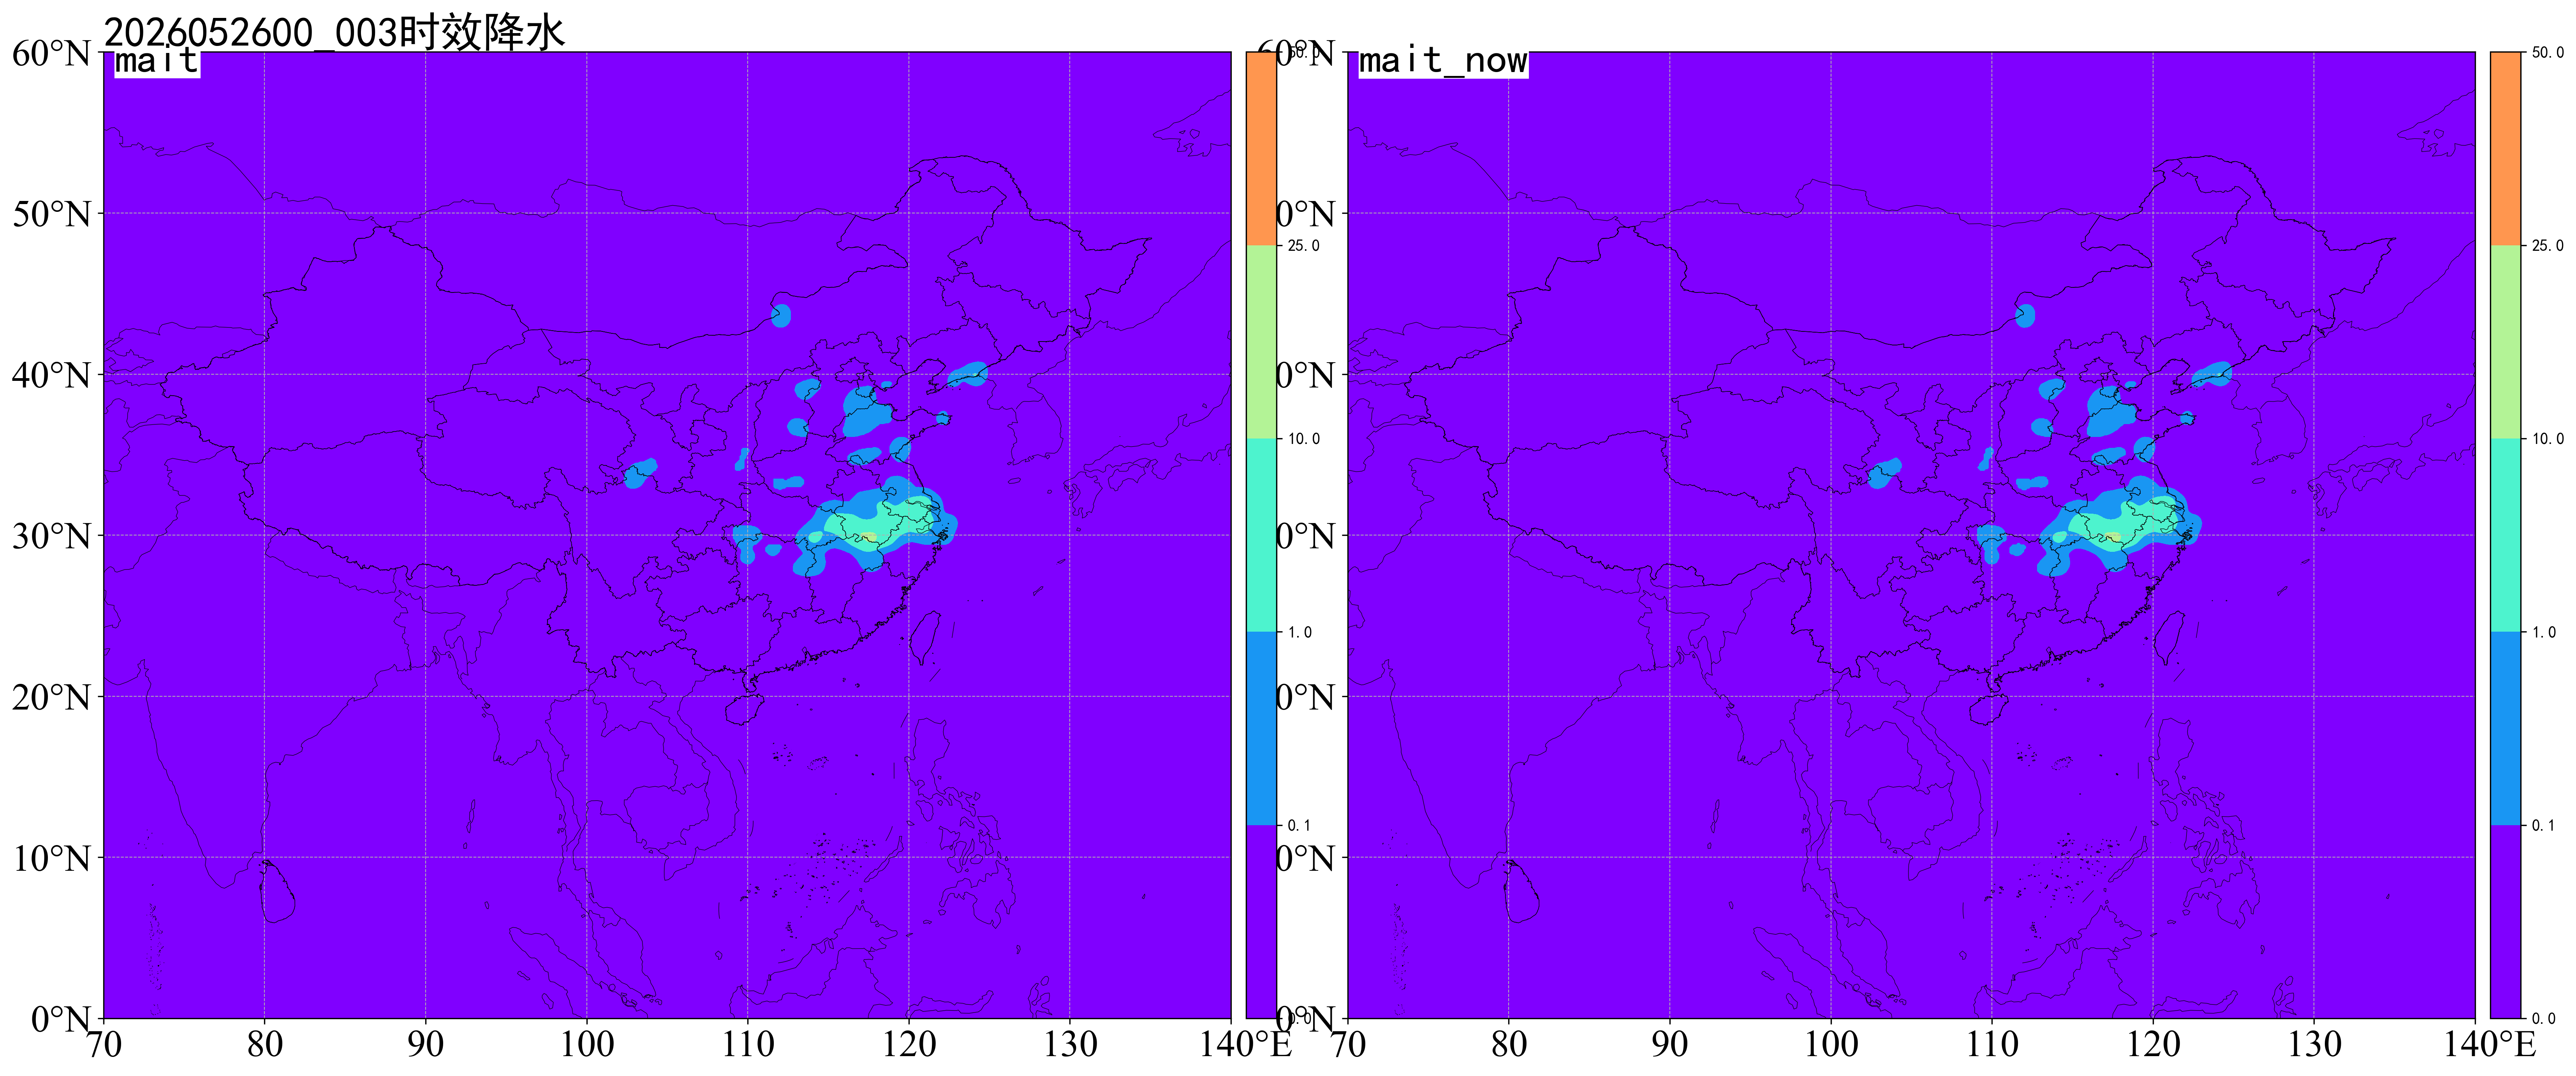

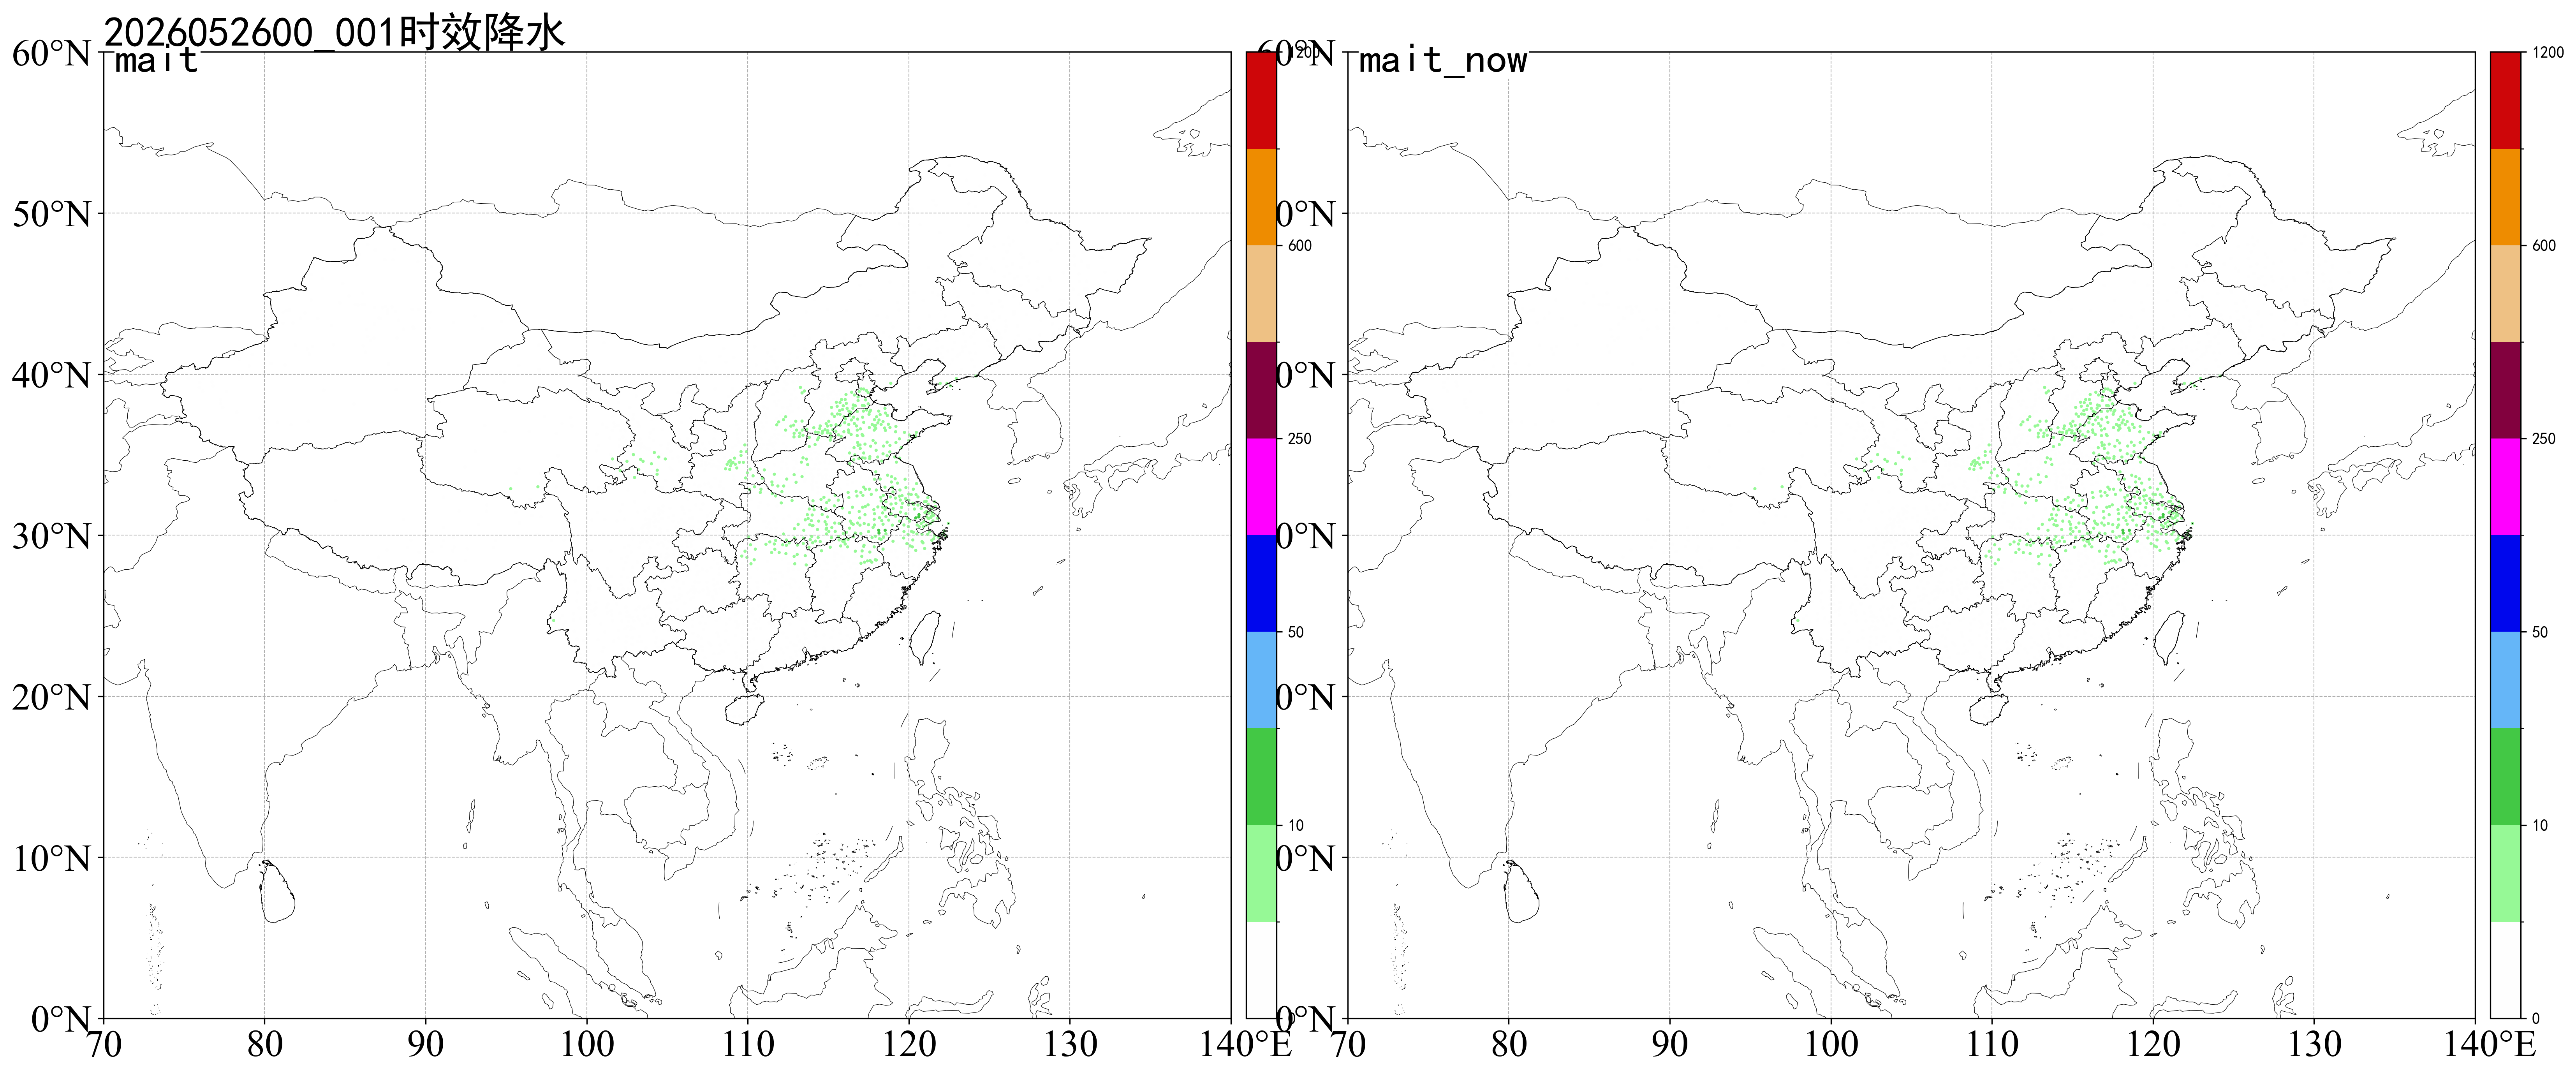

In [2]:
import meteva_base as meb
import numpy as np
import matplotlib.pyplot as plt
import datetime

mait = r"D:/Work/mait_st/result/YYYYMMDD/YYYYMMDDHH.TTT.m4"
mait_now = r"D:/Work/mait_1h/resource/data/result/YYYYMMDD/YYYYMMDDHH.TTT.m4"
dtime = 3
ftime = "2026052600"

fo_time = datetime.datetime.strptime(ftime, "%Y%m%d%H")
mt_2_path = meb.get_path(mait, fo_time, dtime)
mt_1_path = meb.get_path(mait_now, fo_time, dtime)

mt1_grd = meb.read_griddata_from_micaps4(mt_2_path)
mt2_grd = meb.read_griddata_from_micaps4(mt_1_path)

map_extend = [70.0, 140.0, 0, 60.0]
axs = meb.creat_axs(2, map_extend, ncol=2, add_index=["mait", "mait_now"], sup_title=f"{ftime}_{dtime:03d}时效降水", sup_fontsize=26, wspace=1, height=26, width=26)
clevs = np.array([0, 0.1, 1, 10, 25, 50])
meb.add_contourf(axs[0], mt1_grd, cmap="rainbow", clevs=clevs, add_colorbar=True)
meb.add_contourf(axs[1], mt2_grd, cmap="rainbow", clevs=clevs, add_colorbar=True)


mait = r"D:/Work/mait_st/result/YYYYMMDD/YYYYMMDDHH.TTT.m3"
mait_now = r"D:/Work/mait_1h/resource/data/result/YYYYMMDD/YYYYMMDDHH.TTT.m3"
dtime = 1

fo_time = datetime.datetime.strptime(ftime, "%Y%m%d%H")
mt_2_path = meb.get_path(mait, fo_time, dtime)
mt_1_path = meb.get_path(mait_now, fo_time, dtime)

mt1_sta = meb.read_stadata_from_micaps3(mt_2_path)
mt2_sta = meb.read_stadata_from_micaps3(mt_1_path)

axs = meb.creat_axs(2, map_extend, ncol=2, add_index=["mait", "mait_now"], sup_title=f"{ftime}_{dtime:03d}时效降水", sup_fontsize=26, wspace=1, height=26, width=26)
clevs = np.array([0, 0.1, 1, 10, 25, 50])
meb.add_scatter(axs[0], mt1_sta, cmap = meb.cmaps.rain_24h,add_colorbar=True,alpha=1)
meb.add_scatter(axs[1], mt2_sta, cmap = meb.cmaps.rain_24h,add_colorbar=True,alpha=1)

## 9. 结果检验


        level                time  dtime     id     lon    lat        ob  \
0           0 2026-04-15 16:00:00      1  50136  122.52  52.97       0.5   
1           0 2026-04-15 16:00:00      1  50137  122.37  53.47       1.0   
2           0 2026-04-15 16:00:00      1  50246  124.72  52.35       0.0   
3           0 2026-04-15 16:00:00      1  50247  123.57  52.03       0.0   
4           0 2026-04-15 16:00:00      1  50349  124.40  51.67       0.0   
...       ...                 ...    ...    ...     ...    ...       ...   
694363      0 2026-04-21 04:00:00     24  59945  109.70  18.65  999999.0   
694364      0 2026-04-21 04:00:00     24  59948  109.58  18.22  999999.0   
694365      0 2026-04-21 04:00:00     24  59951  110.33  18.80  999999.0   
694366      0 2026-04-21 04:00:00     24  59954  110.03  18.55  999999.0   
694367      0 2026-04-21 04:00:00     24  59981  112.33  16.83  999999.0   

        mait_st   mait_1h  
0           0.0       0.0  
1           0.0       0.0  
2  

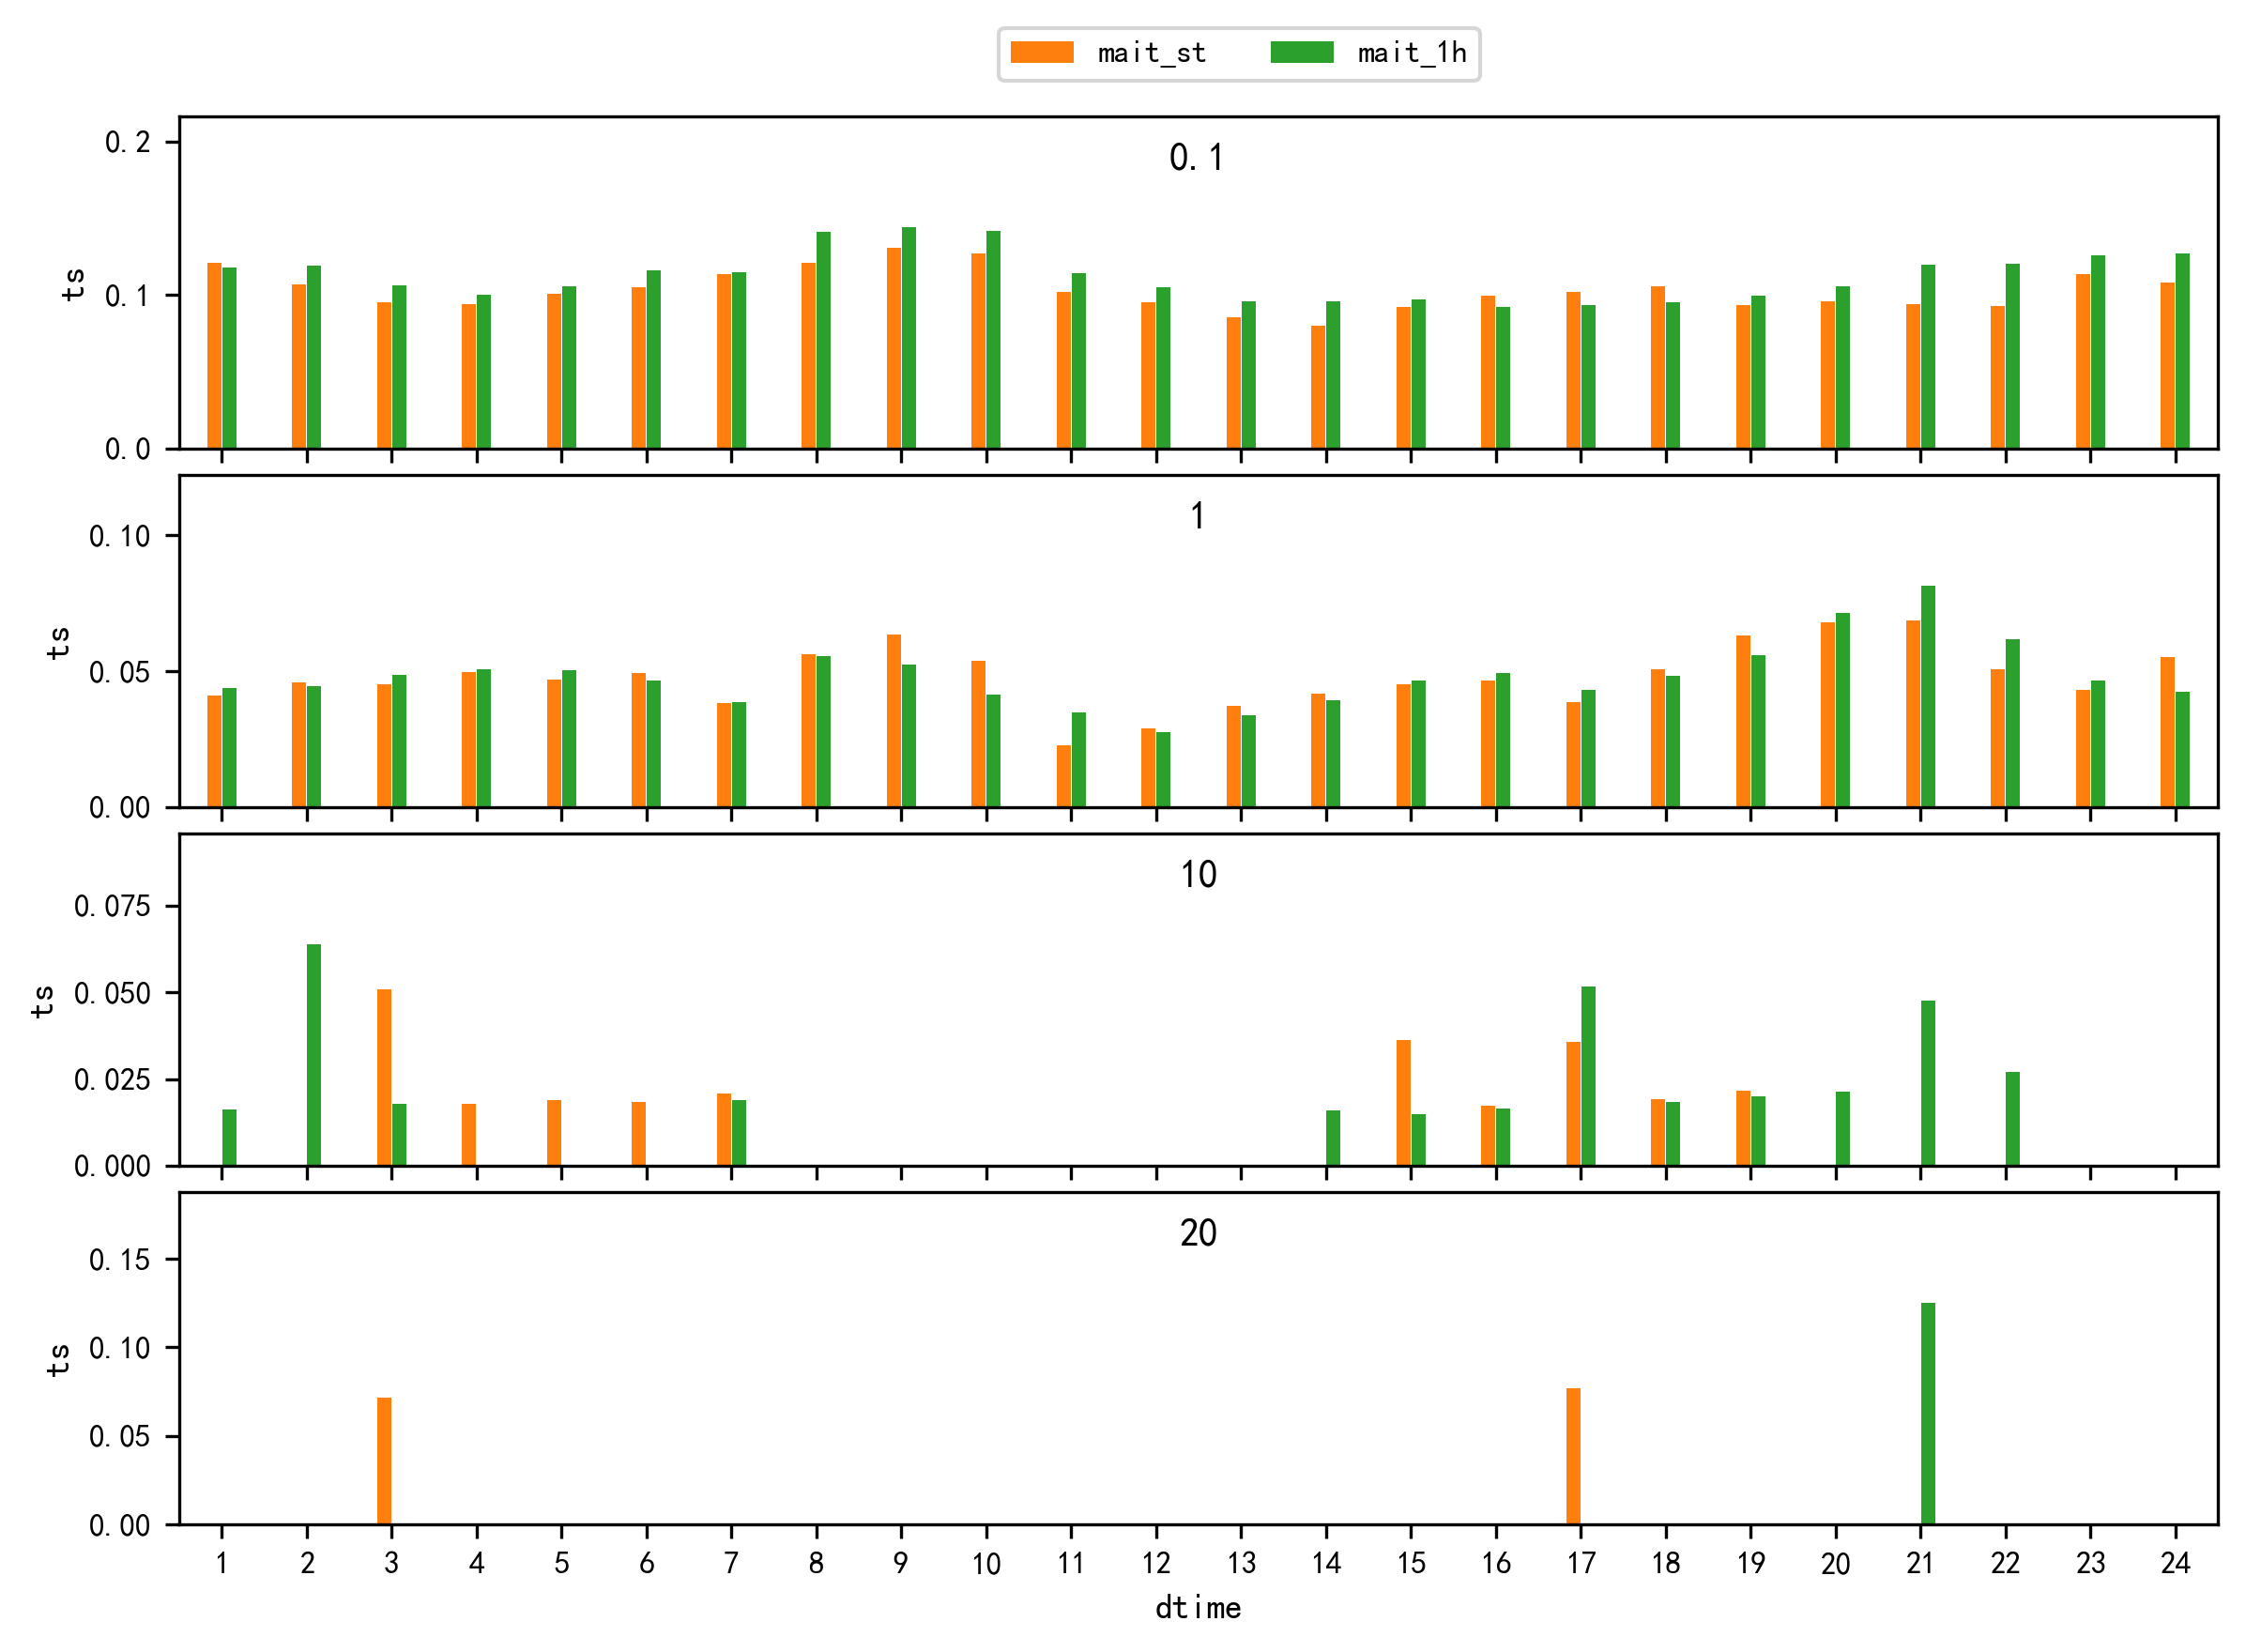

    时效     产品名称       0.1         1        10        20
0    1  mait_st  0.120952  0.041009  0.000000  0.000000
1    1  mait_1h  0.117988  0.043887  0.016393  0.000000
2    2  mait_st  0.107143  0.045902  0.000000  0.000000
3    2  mait_1h  0.119184  0.044586  0.063830  0.000000
4    3  mait_st  0.095326  0.045089  0.050847  0.071429
5    3  mait_1h  0.106331  0.048589  0.017857  0.000000
6    4  mait_st  0.094247  0.049679  0.017857  0.000000
7    4  mait_1h  0.100302  0.050613  0.000000  0.000000
8    5  mait_st  0.100679  0.046926  0.018868  0.000000
9    5  mait_1h  0.105711  0.050473  0.000000  0.000000
10   6  mait_st  0.105362  0.049404  0.018519  0.000000
11   6  mait_1h  0.116350  0.046549  0.000000  0.000000
12   7  mait_st  0.113622  0.038261  0.020833  0.000000
13   7  mait_1h  0.115190  0.038591  0.018868  0.000000
14   8  mait_st  0.120952  0.056338  0.000000  0.000000
15   8  mait_1h  0.141207  0.055465  0.000000  0.000000
16   9  mait_st  0.130674  0.063636  0.000000  0

,时效,产品名称,0.1,1,10,20
0,1,mait_st,0.120952,0.041009,0.000000,0.000000
1,1,mait_1h,0.117988,0.043887,0.016393,0.000000
2,2,mait_st,0.107143,0.045902,0.000000,0.000000
3,2,mait_1h,0.119184,0.044586,0.063830,0.000000
4,3,mait_st,0.095326,0.045089,0.050847,0.071429
5,3,mait_1h,0.106331,0.048589,0.017857,0.000000
6,4,mait_st,0.094247,0.049679,0.017857,0.000000
7,4,mait_1h,0.100302,0.050613,0.000000,0.000000
8,5,mait_st,0.100679,0.046926,0.018868,0.000000
9,5,mait_1h,0.105711,0.050473,0.000000,0.000000


In [1]:
import meteva
import pandas as pd
import numpy as np
import meteva_base as meb
import meteva.product as mpd

import meteva.method as mem
import meteva.product as mpd

from datetime import datetime, timedelta

def get_ts(sta_all, grade_list, product_list, h5_file, plot="bar"):
    result = mpd.score(sta_all, mem.ts, grade_list=grade_list, g="dtime", plot=plot, save_path=f"ts_{plot}.png", show=True)
    res_array = result[0]
    dtimes = result[1]
    df_list = []

    for i, shixiao in enumerate(dtimes):
        for j, product in enumerate(product_list):
            row = [product] + res_array[i, j].tolist()
            df_list.append([shixiao] + row)

    columns = ["时效", "产品名称"] + grade_list

    df = pd.DataFrame(df_list, columns=columns)
    df.to_hdf(h5_file, key="ts", mode='a')
    print(df)

    return df

h5_file = r"D:\data1\zhongzhuan\20260525\mait_1_sta_all.h5"
sta_all = pd.read_hdf(h5_file, key="sta_all")
sta_all.rename(columns={'mait_chen': 'mait_1h'}, inplace=True)
print(sta_all)

product_list = ["mait_st", "mait_1h"]
grade_list = [0.1, 1, 10, 20]
get_ts(sta_all, grade_list, product_list, h5_file)  # 保存ts评分结果